# Multiparameter Persistence on Medical Imaging: A Cubical Bifiltration Approach

This notebook provides a self-contained demonstration of multiparameter persistent homology on grid-structured medical data (RetinaMNIST). Following the mathematical foundations detailed in the repository README, we compute a 2D cubical bifiltration via the Signed Euclidean Distance Transform (SEDT), restrict it along an admissible slicing line $L$, and vectorize the resulting 1-parameter persistence module into Bubenik persistence landscapes.

## 1. Environment Setup and Data Ingestion

We load the necessary scientific computing libraries and retrieve a representative $28 \times 28$ sample from the RetinaMNIST dataset. The image intensities are scaled using min-max normalization to strictly match the theoretical domain $[0, 1]$.

1. First of all, we install all the libraries required for this project in a python environment in a power shell terminal:

```bash
# On Linux / macOS:
python -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
# On Windows (PowerShell):
python -m venv .venv
.\.venv\Scripts\Activate.ps1
pip install -r requirements.txt
```

2. Next, we download and process the image

Image dimensions: 28x28 pixels
Intensity domain: [0.000, 1.000]


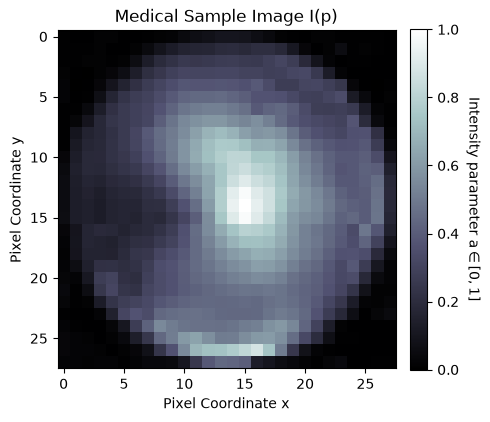

In [19]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- 1. Dataset Directory and File Management ---
current_dir = Path.cwd()
script_dir = current_dir.parent if current_dir.name == "notebooks" else current_dir
data_dir = script_dir / "data"
image_path = data_dir / "sample_retina.png"
os.makedirs(data_dir, exist_ok=True)

# Download and persist the sample image locally if not already present
if not os.path.exists(image_path):
    import medmnist
    from medmnist import RetinaMNIST

    print("Downloading sample image from RetinaMNIST...")
    dataset = RetinaMNIST(split="train", download=True)
    sample_pil, _ = dataset[0]
    sample_pil.save(image_path)
    print(f"Sample image successfully saved to {image_path}")

# --- 2. Image Loading and Preprocessing ---
img_pil = Image.open(image_path).convert("L")
img_raw = np.array(img_pil, dtype=np.float64)

# Min-max normalization to strictly map pixel values to [0, 1]
img = (img_raw - img_raw.min()) / (img_raw.max() - img_raw.min())

height, width = img.shape
print(f"Image dimensions: {height}x{width} pixels")
print(f"Intensity domain: [{img.min():.3f}, {img.max():.3f}]")

# --- 3. Visualization ---
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(img, cmap="bone", origin="upper")

# Using raw strings (r"...") prevents invalid escape sequence warnings in LaTeX expressions
ax.set_title(r"Medical Sample Image $\mathcal{I}(p)$", fontsize=12)
ax.set_xlabel("Pixel Coordinate $x$")
ax.set_ylabel("Pixel Coordinate $y$")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"Intensity parameter $a \in [0, 1]$", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

## 2. Discrete Cubical Bifiltration Operator

We evaluate the discrete thickened superlevel sets $V_{a, t} = \{p \in K_2 \mid D_a(p) \ge -t\}$ over a regular grid, combining intensity thresholding $a$ with spatial distance transforms $t$ (SEDT). The implementation verifies the functorial inclusion of subcomplexes along an ordered sequence in $(\mathbb{R}^{\mathrm{op}} \times \mathbb{R}, \le)$.

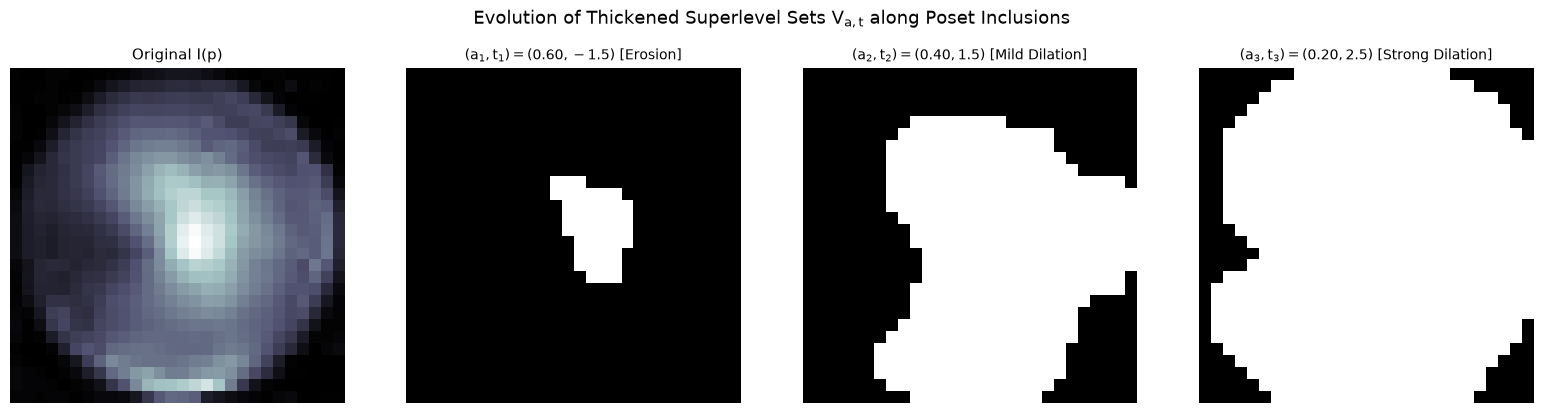

Functorial inclusion check V_1 <= V_2: True
Functorial inclusion check V_2 <= V_3: True


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

# --- 1. Definition of the Bifiltration Operator ---

def compute_sedt(image: np.ndarray, a: float) -> np.ndarray:
    """
    Compute the Signed Euclidean Distance Transform (SEDT) of the superlevel set V_a.
    
    Note on discrete grid metrics:
        Pixel center-to-center distances yield dist >= 1.0 for all boundary pixels.
        Consequently, spatial changes (erosion/dilation) take effect for |t| >= 1.0.

    Parameters:
        image (np.ndarray): 2D grayscale image normalized in [0, 1].
        a (float): Intensity threshold.
        
    Returns:
        np.ndarray: SEDT grid with positive values inside V_a and negative values outside.
    """
    v_a = image >= a
    
    # Handle degenerate edge cases where the superlevel set is empty or complete
    if not np.any(v_a):
        return np.full(image.shape, -np.inf)
    if np.all(v_a):
        return np.full(image.shape, np.inf)
        
    # dist_in measures Euclidean distance from foreground pixels to the nearest background pixel
    dist_in = distance_transform_edt(v_a)
    # dist_out measures Euclidean distance from background pixels to the nearest foreground pixel
    dist_out = distance_transform_edt(~v_a)
    
    return dist_in - dist_out

def compute_thickened_mask(image: np.ndarray, a: float, t: float) -> np.ndarray:
    """
    Compute the discrete thickened superlevel set mask V_{a, t}.
    
    Parameters:
        image (np.ndarray): 2D grayscale image normalized in [0, 1].
        a (float): Intensity threshold.
        t (float): Spatial distance parameter (dilation if t > 0, erosion if t < 0).
        
    Returns:
        np.ndarray: Boolean array where True indicates pixel membership in V_{a, t}.
    """
    sedt = compute_sedt(image, a)
    return sedt >= -t

# --- 2. Evaluation across an Admissible Monotone Sequence ---

# Sample three points satisfying (a_1, t_1) <= (a_2, t_2) <= (a_3, t_3) in (R^op x R, <=)
# Note: a decreases while t increases, guaranteeing monotonic inclusion V_1 \subseteq V_2 \subseteq V_3
sample_params = [
    (0.60, -1.5, r"$(a_1, t_1) = (0.60, -1.5)$ [Erosion]"),
    (0.40,  1.5, r"$(a_2, t_2) = (0.40, 1.5)$ [Mild Dilation]"),
    (0.20,  2.5, r"$(a_3, t_3) = (0.20, 2.5)$ [Strong Dilation]")
]

masks = [compute_thickened_mask(img, a, t) for a, t, _ in sample_params]

# --- 3. Multi-panel Visualization ---

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original image reference
axes[0].imshow(img, cmap="bone", origin="upper")
axes[0].set_title(r"Original $\mathcal{I}(p)$", fontsize=11)
axes[0].axis("off")

# Render each thickened mask
for i, (mask, (_, _, label)) in enumerate(zip(masks, sample_params), start=1):
    axes[i].imshow(mask, cmap="binary_r", origin="upper")
    axes[i].set_title(label, fontsize=10)
    axes[i].axis("off")

plt.suptitle(r"Evolution of Thickened Superlevel Sets $V_{a, t}$ along Poset Inclusions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Verification of monotonic subcomplex inclusion
inc_1_in_2 = np.all(masks[0] <= masks[1])
inc_2_in_3 = np.all(masks[1] <= masks[2])
print(f"Functorial inclusion check V_1 <= V_2: {inc_1_in_2}")
print(f"Functorial inclusion check V_2 <= V_3: {inc_2_in_3}")

## 3. 1D Slicing along an Admissible Trajectory $L$

To compute tractable topological summaries, we restrict the bifiltration along an isometric slicing line $L(s) = (a_0 - s v_a, \, t_0 + s v_t)$ with unit speed $\|v\|_\infty = 1.0$. Evaluating the earliest arrival step across a fine regular mesh $s \in [s_{\min}, s_{\max}]$ yields the top-dimensional cell (pixel) entry time matrix $S(p) \in \mathbb{R}^{28 \times 28}$.

Filtration matrix shape: (28, 28)
Entry time range s(p): [0.000, 4.480]


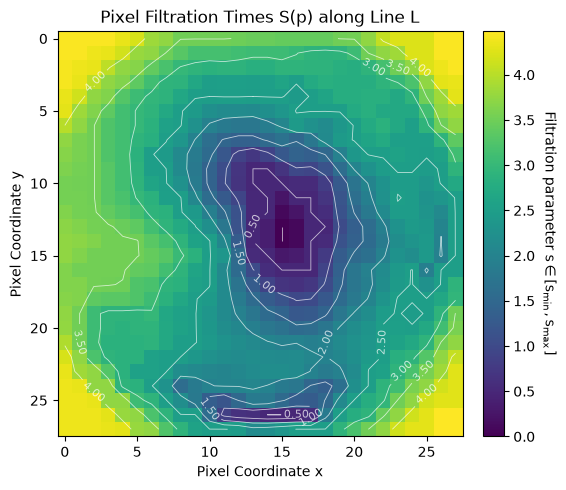

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Admissible Line Parameterization ---
# Direction vector with positive slopes (v_a > 0, v_t > 0)
# This guarantees that as s increases, a(s) decreases and t(s) increases
a_0, t_0 = 0.85, -1.5
v_a, v_t = 0.1875, 1.0

# Discretize the parameter s across a fine regular grid
n_steps = 461
s_min, s_max = 0.0, 4.60
s_values = np.linspace(s_min, s_max, n_steps)

# --- 2. Computation of Pixel Entry Times S(p) ---
# Initialize the filtration matrix with infinity
S = np.full(img.shape, np.inf, dtype=np.float64)

for s in s_values:
    # Parametric equations of the slicing line L
    a_s = a_0 - s * v_a
    t_s = t_0 + s * v_t
    
    # Evaluate the thickened superlevel set at (a(s), t(s))
    mask = compute_thickened_mask(img, a_s, t_s)
    
    # Identify pixels entering the complex for the first time at step s
    new_entries = mask & np.isinf(S)
    S[new_entries] = s
    
    # Early stop if all pixels in the lattice have entered the filtration
    if not np.any(np.isinf(S)):
        break

# Assign s_max to any remaining background boundary pixels
S[np.isinf(S)] = s_max

print(f"Filtration matrix shape: {S.shape}")
print(f"Entry time range s(p): [{S.min():.3f}, {S.max():.3f}]")

# --- 3. Visualization of the Sliced Filtration Surface ---
fig, ax = plt.subplots(figsize=(6, 5))

# Heatmap displaying the filtration arrival times
im = ax.imshow(S, cmap="viridis", origin="upper")

# Overlay contour lines to visualize the filtration front propagation
contours = ax.contour(S, levels=8, colors="white", linewidths=0.6, alpha=0.7)
ax.clabel(contours, inline=True, fontsize=8, fmt="%.2f")

ax.set_title(r"Pixel Filtration Times $S(p)$ along Line $L$", fontsize=12)
ax.set_xlabel("Pixel Coordinate $x$")
ax.set_ylabel("Pixel Coordinate $y$")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"Filtration parameter $s \in [s_{\min}, s_{\max}]$", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

## 4. 1D Persistent Homology via GUDHI

Using GUDHI's `CubicalComplex` engine, we compute the persistence barcode $\mathcal{B}(\mathcal{M}_k\vert{}_L)$ for homological degrees $k \in \{0, 1\}$ over coefficients in $\mathbb{Z}/2\mathbb{Z}$. The filtration matrix $S$ defines the entry times of top-dimensional cells (pixels), naturally inducing the subcomplex filtration where lower-dimensional faces enter alongside their earliest incident pixel.

H_0 features identified: 5
H_1 features identified: 6


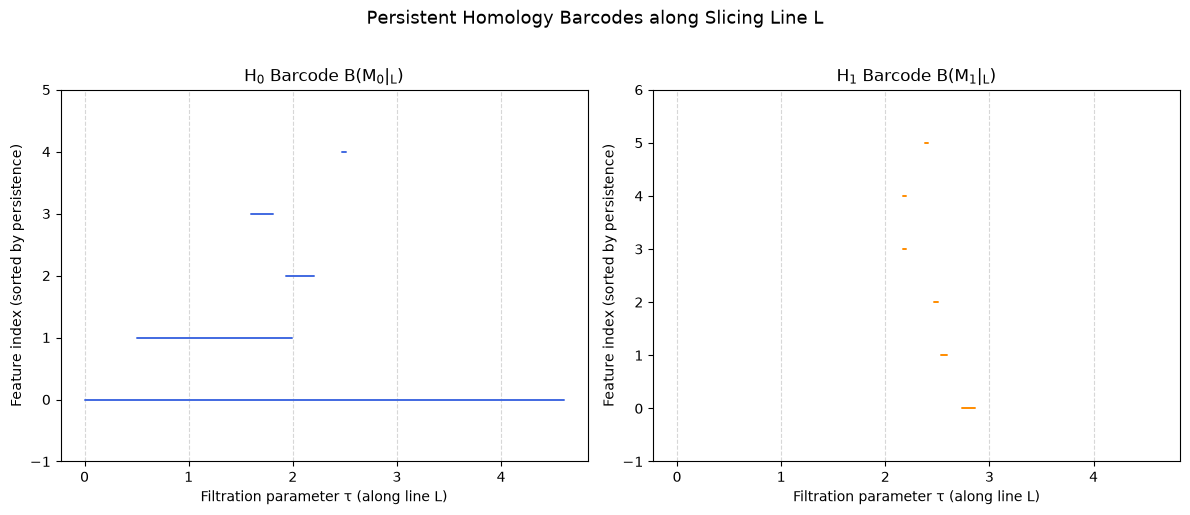

In [22]:
import gudhi
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Cubical Complex Construction and Persistence Computation ---
# Build the cubical complex from the grid of entry times S
cubical = gudhi.CubicalComplex(top_dimensional_cells=S)

# Compute persistent homology over Z/2Z coefficients
cubical.compute_persistence(homology_coeff_field=2)

# Extract persistence intervals for degrees k = 0 and k = 1
intervals_0 = cubical.persistence_intervals_in_dimension(0)
intervals_1 = cubical.persistence_intervals_in_dimension(1)

print(f"H_0 features identified: {len(intervals_0)}")
print(f"H_1 features identified: {len(intervals_1)}")

# --- 2. Visualization of the 1D Persistence Barcodes ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

def render_barcode(ax, intervals, title, color):
    """
    Render sorted horizontal persistence bars for a given homological degree.
    """
    if len(intervals) == 0:
        ax.text(0.5, 0.5, "No persistent features detected in $H_1$", 
                ha="center", va="center", transform=ax.transAxes, fontsize=11, color="gray")
        ax.set_title(title, fontsize=12)
        ax.set_xlabel(r"Filtration parameter $\tau$ (along line $L$)")
        ax.set_yticks([])
        return

    # Sort intervals by persistence lifespan (death - birth) in descending order
    processed_bars = []
    for birth, death in intervals:
        death_val = s_max if np.isinf(death) else death
        processed_bars.append((birth, death_val, death_val - birth))
    
    processed_bars.sort(key=lambda item: item[2], reverse=True)

    for idx, (birth, death, _) in enumerate(processed_bars):
        ax.plot([birth, death], [idx, idx], color=color, linewidth=1.4, solid_capstyle="round")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r"Filtration parameter $\tau$ (along line $L$)")
    ax.set_ylabel("Feature index (sorted by persistence)")
    ax.set_ylim(-1, len(processed_bars))
    ax.grid(axis="x", linestyle="--", alpha=0.5)

render_barcode(axes[0], intervals_0, r"$H_0$ Barcode $\mathcal{B}(\mathcal{M}_0|_L)$", color="royalblue")
render_barcode(axes[1], intervals_1, r"$H_1$ Barcode $\mathcal{B}(\mathcal{M}_1|_L)$", color="darkorange")

plt.suptitle(r"Persistent Homology Barcodes along Slicing Line $L$", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Bubenik Persistence Landscapes

We transform the persistence diagrams into functional feature vectors using `gudhi.representations.Landscape`. Essential classes with infinite lifetime are capped at $s_{\max} = 4.60$ to ensure compact support, evaluating layers $q \in \{1, 2, 3\}$ across the filtration range.

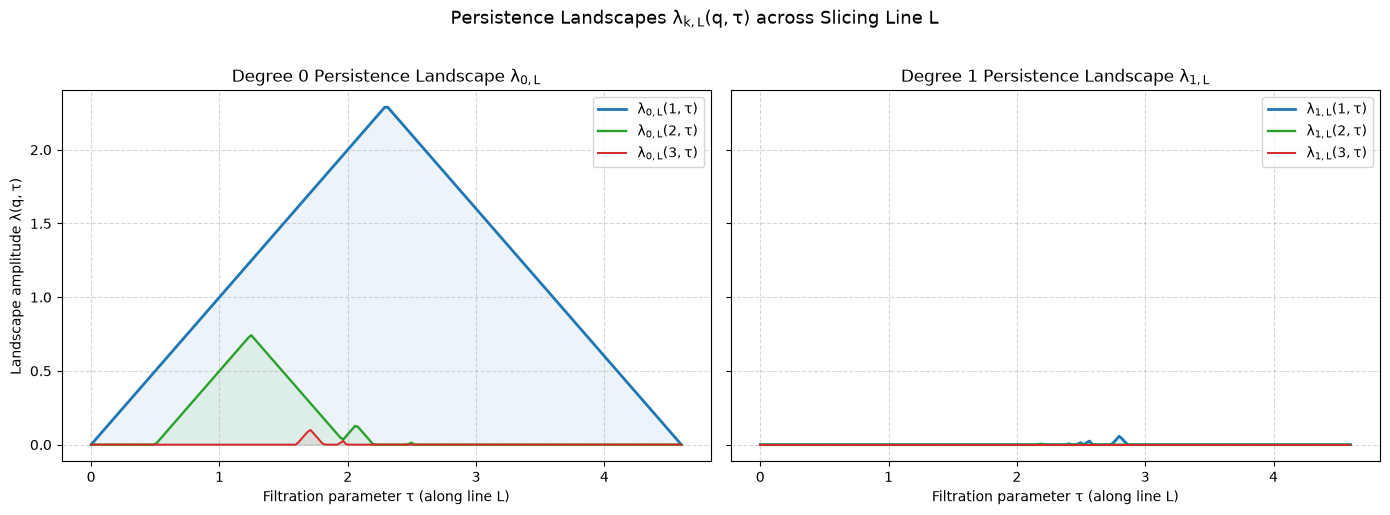

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from gudhi.representations import Landscape

# --- 1. Interval Preparation and Truncation ---
def prepare_diagram(intervals: list, max_val: float) -> np.ndarray:
    """
    Format persistence intervals for GUDHI representations,
    capping essential features (death = inf) at max_val and removing zero-length bars.
    """
    valid_bars = []
    for birth, death in intervals:
        death_val = max_val if np.isinf(death) else death
        if death_val > birth:
            valid_bars.append([birth, death_val])
            
    if len(valid_bars) == 0:
        return np.empty((0, 2), dtype=np.float64)
    return np.array(valid_bars, dtype=np.float64)

diag_0 = prepare_diagram(intervals_0, s_max)
diag_1 = prepare_diagram(intervals_1, s_max)

# --- 2. Computation of Persistence Landscapes via GUDHI ---
num_landscapes = 3
resolution = 200
tau_mesh = np.linspace(s_min, s_max, resolution)

landscape_model = Landscape(
    num_landscapes=num_landscapes,
    resolution=resolution,
    sample_range=[s_min, s_max]
)
# GUDHI's Landscape class rotates persistence diagrams by 45 degrees using an
# L2-orthonormal basis, which scales landscape triangle heights by sqrt(2).
# We divide by sqrt(2) to align with Bubenik's canonical L_infinity definition
# where the peak of an interval [b, d] reaches height (d - b) / 2.
# Compute landscapes for H_0
landscapes_0 = landscape_model.fit_transform([diag_0])[0]
landscapes_0 = (landscapes_0 / np.sqrt(2)).reshape(num_landscapes, resolution)

# Compute landscapes for H_1 (safely handling empty diagrams)
if len(diag_1) > 0:
    landscapes_1 = landscape_model.fit_transform([diag_1])[0]
    landscapes_1 = (landscapes_1 / np.sqrt(2)).reshape(num_landscapes, resolution)
else:
    landscapes_1 = np.zeros((num_landscapes, resolution))

# --- 3. Multi-layer Landscape Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = ["#1f77b4", "#2ca02c", "#d62728"]

# Render H_0 Landscapes
for q in range(num_landscapes):
    axes[0].plot(
        tau_mesh, 
        landscapes_0[q], 
        label=rf"$\lambda_{{0, L}}({q+1}, \tau)$", 
        color=colors[q], 
        linewidth=2.0 - 0.3 * q
    )
    axes[0].fill_between(tau_mesh, 0, landscapes_0[q], color=colors[q], alpha=0.08)

axes[0].set_title(r"Degree 0 Persistence Landscape $\lambda_{0, L}$", fontsize=12)
axes[0].set_xlabel(r"Filtration parameter $\tau$ (along line $L$)")
axes[0].set_ylabel(r"Landscape amplitude $\lambda(q, \tau)$")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="upper right", frameon=True)

# Render H_1 Landscapes
for q in range(num_landscapes):
    axes[1].plot(
        tau_mesh, 
        landscapes_1[q], 
        label=rf"$\lambda_{{1, L}}({q+1}, \tau)$", 
        color=colors[q], 
        linewidth=2.0 - 0.3 * q
    )
    axes[1].fill_between(tau_mesh, 0, landscapes_1[q], color=colors[q], alpha=0.08)

axes[1].set_title(r"Degree 1 Persistence Landscape $\lambda_{1, L}$", fontsize=12)
axes[1].set_xlabel(r"Filtration parameter $\tau$ (along line $L$)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="upper right", frameon=True)

plt.suptitle(r"Persistence Landscapes $\lambda_{k, L}(q, \tau)$ across Slicing Line $L$", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Composite Pipeline Visualization and Asset Export

We assemble the end-to-end homological pipeline into a unified $2 \times 2$ panel figure: input image contour, arrival time surface $S(p)$, 1D barcodes, and multi-layer persistence landscapes. The output is exported to `assets/pipeline_walkthrough.png` at publication resolution (300 DPI).

Panel composite image successfully exported to: c:\Users\ignac\git_projects\multiparameter_persistence\assets\pipeline_walkthrough.png


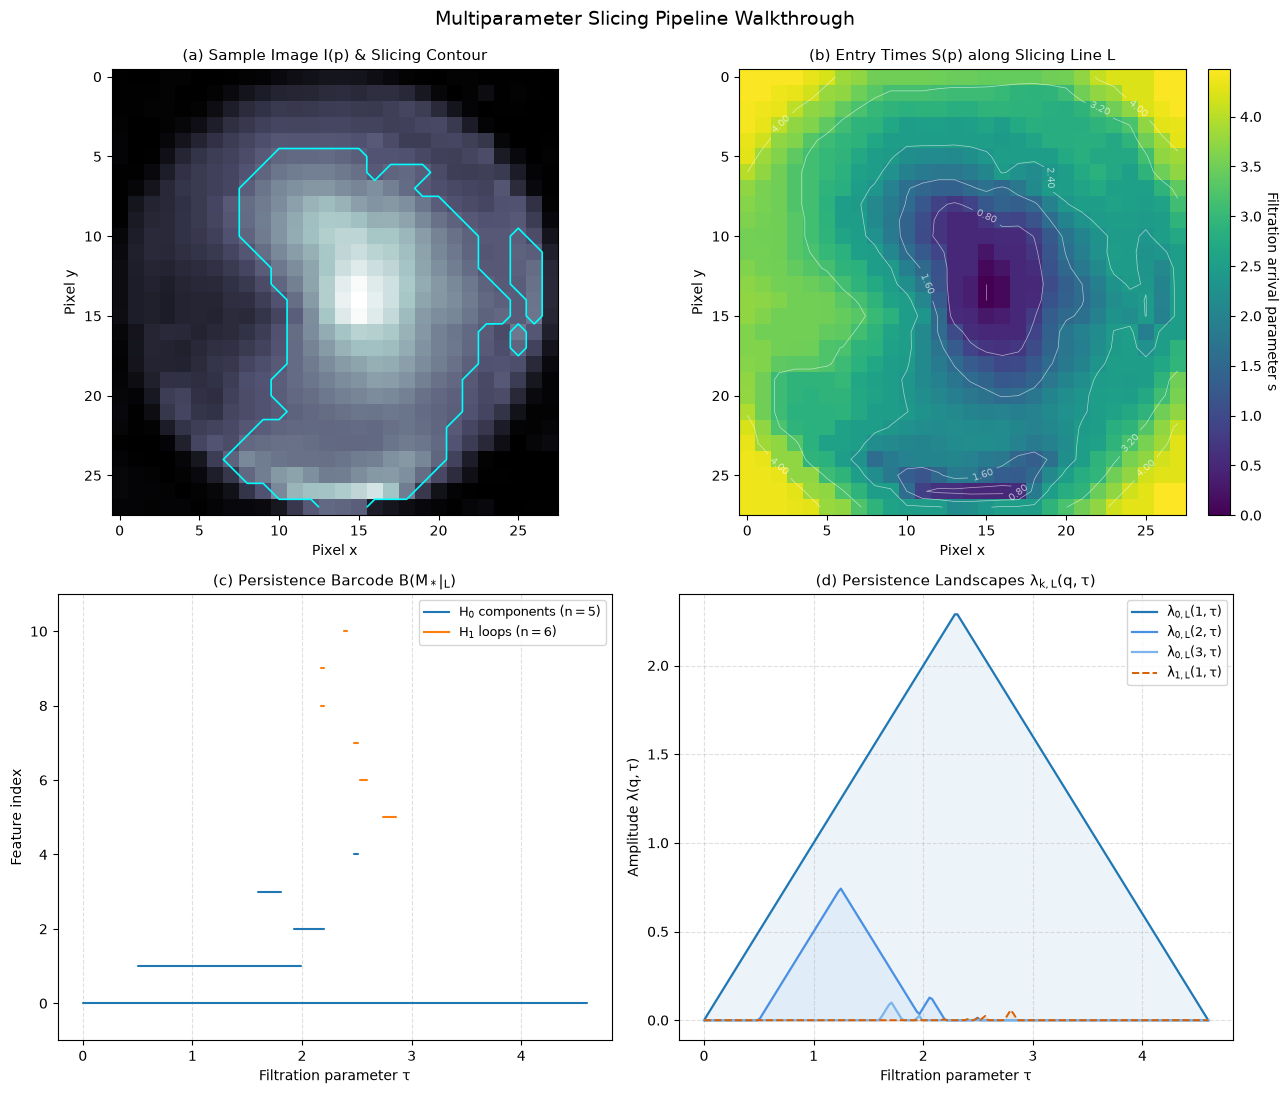

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Export Control and Directory Management ---
EXPORT_README_ASSET = True
folder_name = "assets" if EXPORT_README_ASSET else "outputs"
output_dir = script_dir / folder_name
os.makedirs(output_dir, exist_ok=True)

walkthrough_filename = "pipeline_walkthrough.png" if EXPORT_README_ASSET else "test_run.png"
output_path = output_dir / walkthrough_filename

# --- 2. Composite Figure Layout (2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# Panel (a): Original medical image with an illustrative thickened contour
axes[0, 0].imshow(img, cmap="bone", origin="upper")
ref_mask = compute_thickened_mask(img, a=0.40, t=0.90)
axes[0, 0].contour(ref_mask, levels=[0.5], colors="cyan", linewidths=1.2)
axes[0, 0].set_title(r"(a) Sample Image $\mathcal{I}(p)$ & Slicing Contour", fontsize=11)
axes[0, 0].set_xlabel("Pixel $x$")
axes[0, 0].set_ylabel("Pixel $y$")

# Panel (b): Sliced filtration arrival times S(p)
im_s = axes[0, 1].imshow(S, cmap="viridis", origin="upper")
contours_s = axes[0, 1].contour(S, levels=6, colors="white", linewidths=0.5, alpha=0.6)
axes[0, 1].clabel(contours_s, inline=True, fontsize=7, fmt="%.2f")
axes[0, 1].set_title(r"(b) Entry Times $S(p)$ along Slicing Line $L$", fontsize=11)
axes[0, 1].set_xlabel("Pixel $x$")
axes[0, 1].set_ylabel("Pixel $y$")
cbar_s = fig.colorbar(im_s, ax=axes[0, 1], fraction=0.046, pad=0.04)
cbar_s.set_label(r"Filtration arrival parameter $s$", rotation=270, labelpad=12)

# Panel (c): 1D persistent homology barcodes (H_0 and H_1)
ax_bar = axes[1, 0]
y_offset = 0

# Sort H_0 bars by persistence lifespan in descending order
sorted_h0 = sorted([[b, s_max if np.isinf(d) else d] for b, d in intervals_0], key=lambda x: x[1] - x[0], reverse=True)
for b, d in sorted_h0:
    ax_bar.plot([b, d], [y_offset, y_offset], color="#1f77b4", linewidth=1.5, solid_capstyle="round")
    y_offset += 1

# Sort H_1 bars by persistence lifespan in descending order
sorted_h1 = sorted([[b, s_max if np.isinf(d) else d] for b, d in intervals_1], key=lambda x: x[1] - x[0], reverse=True)
for b, d in sorted_h1:
    ax_bar.plot([b, d], [y_offset, y_offset], color="#ff7f0e", linewidth=1.5, solid_capstyle="round")
    y_offset += 1

ax_bar.set_title(r"(c) Persistence Barcode $\mathcal{B}(\mathcal{M}_*|_L)$", fontsize=11)
ax_bar.set_xlabel(r"Filtration parameter $\tau$")
ax_bar.set_ylabel("Feature index")
ax_bar.set_ylim(-1, y_offset)
ax_bar.grid(axis="x", linestyle="--", alpha=0.4)

# Legend handles for distinguishing homological degrees
ax_bar.plot([], [], color="#1f77b4", label=rf"$H_0$ components ($n={len(sorted_h0)}$)")
ax_bar.plot([], [], color="#ff7f0e", label=rf"$H_1$ loops ($n={len(sorted_h1)}$)")
ax_bar.legend(loc="upper right", frameon=True, fontsize=9)

# Panel (d): Superimposed persistence landscapes
ax_land = axes[1, 1]
colors_l0 = ["#1f77b4", "#4a90e2", "#7cb5ec"]
colors_l1 = ["#d95f02", "#f28e2b", "#ffbe7d"]

for q in range(num_landscapes):
    ax_land.plot(tau_mesh, landscapes_0[q], color=colors_l0[q], linewidth=1.6, label=rf"$\lambda_{{0, L}}({q+1}, \tau)$")
    ax_land.fill_between(tau_mesh, 0, landscapes_0[q], color=colors_l0[q], alpha=0.08)

if len(diag_1) > 0:
    ax_land.plot(tau_mesh, landscapes_1[0], color=colors_l1[0], linestyle="--", linewidth=1.4, label=r"$\lambda_{1, L}(1, \tau)$")
    ax_land.fill_between(tau_mesh, 0, landscapes_1[0], color=colors_l1[0], alpha=0.08)

ax_land.set_title(r"(d) Persistence Landscapes $\lambda_{k, L}(q, \tau)$", fontsize=11)
ax_land.set_xlabel(r"Filtration parameter $\tau$")
ax_land.set_ylabel(r"Amplitude $\lambda(q, \tau)$")
ax_land.grid(True, linestyle="--", alpha=0.4)
ax_land.legend(loc="upper right", frameon=True, fontsize=9)

# --- 3. Figure Rendering and High-Resolution Export ---
plt.suptitle("Multiparameter Slicing Pipeline Walkthrough", fontsize=14, y=0.99)
plt.tight_layout()

plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Panel composite image successfully exported to: {output_path}")

plt.show()